# Introduction

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.options.display.float_format = '{:,.2f}'.format

In [3]:
from src.helpers import load_view
df_customers = load_view("vw_customer_summary_python")

Design logic behind this view was that only successful orders (not 'canceled' or 'unavailable') should be counted towards total_spent. For the purpose of this analysis we should exclude them.

In [4]:
df_customers.dropna(inplace=True)

Currently, in the view we have customer_tenure_days defined as days between first and last purchase of customer. While it could potentially be a good metric we are dealing with a dataset where majority of customers ordered only once.

Instead, let's add recency metric, defined as days between last purchase and snapshot date (last date in dataset), for RFM analysis.

In [5]:
analysis_date = df_customers["last_purchase_date"].max() + pd.Timedelta(days=1)

df_customers["recency"] = (
    analysis_date -
    df_customers["last_purchase_date"]
).dt.days

In [6]:
features = [
    "recency",
    "total_orders",
    "total_spent"
]

df_customers[features].describe()

,recency,total_orders,total_spent
count,"94,989.00","94,989.00","94,989.00"
mean,287.09,1.04,165.69
std,152.99,0.22,226.74
min,1.00,1.00,9.59
25%,163.00,1.00,63.10
50%,268.00,1.00,107.90
75%,396.00,1.00,182.94
max,772.00,17.00,"13,664.08"


In [7]:
from src.helpers import assign_f_score

df_customers['R_Score'] = pd.qcut(df_customers['recency'], q=5, labels=[5, 4, 3, 2, 1])
df_customers['F_Score'] = df_customers['total_orders'].apply(assign_f_score)
df_customers['M_Score'] = pd.qcut(df_customers['total_spent'], q=5, labels=[1, 2, 3, 4, 5])

### 📊 RFM Segment Descriptions & Marketing Strategies

| Segment Name | RFM Profile (Scores 1-5) | Customer Behavior Description | Recommended Marketing Action |
| :--- | :--- | :--- | :--- |
| **Champions** | High R (4-5), Max F (5) | Your best customers. Bought recently, buy frequently (3+ orders), and spend heavily. | No discounts needed. Offer loyalty program rewards, exclusive early access to new products, and VIP treatment. |
| **Loyal Customers** | Mid R (3), Max F (5) | Reliable power users. They have a history of multiple purchases, but haven't bought in the last few weeks. | Send brand reminders, personalized product recommendations based on past purchases, and ask for feedback/reviews. |
| **At Risk Loyalists** | Low R (1-2), Max F (5) | Former VIPs who have stopped buying. They made 3+ orders in the past but haven't returned for a long time. | High-priority reactivaton. Send an aggressive win-back offer ("We miss you! Here is 20% off your next order") before they completely churn. |
| **Promising Loyalists** | High R (4-5), Mid F (3) | New repeat buyers. They just made their second purchase very recently. Show great potential. | Welcome them to the community. Focus on cross-selling. Offer a small incentive for their 3rd purchase to solidify their loyalty. |
| **Need Attention** | Mid R (3), Mid F (3) | Bought exactly twice, but their activity is starting to slow down. | Send time-limited offers or free shipping triggers to stimulate another purchase before they drift away. |
| **About to Sleep** | Low R (1-2), Mid F (3) | Bought twice in the past, but it was a long time ago. They are losing interest. | Low-cost email re-engagement campaigns. Showcase "What's new on the platform" since their last visit. |
| **High-Value Newcomers** | High R (4-5), Low F (1), High M (4-5) | First-time buyers who made a single, very expensive purchase recently (Big Spenders). | High priority. Send a personalized thank-you note and an immediate hook (e.g., a cashback voucher) for a second purchase to prevent them from being a one-timer. |
| **Recent One-Timers** | High R (4-5), Low F (1), Low M (1-3) | Standard new customers who just made their first small/average purchase. | Standard onboarding flow: tutorial on how to use the platform, newsletter subscription, and dynamic product recommendations. |
| **Potential Spenders** | Mid R (3), Low F (1), High M (4-5) | Made one large purchase some time ago, but haven't interacted since. | Send a tailored offer for high-end products or categories related to their single expensive purchase. |
| **Average One-Timers** | Mid R (3), Low F (1), Low M (1-3) | The typical "average" customer who bought once, spent a standard amount, and is now passive. | Automated standard marketing campaigns, seasonal sales announcements, and popular item recommendations. |
| **Can't Lose Them** | Low R (1-2), Low F (1), High M (4-5) | Made one huge purchase a long time ago and never returned. | Check order history for potential bad experiences (delivery delays/refunds). If clean, try a massive "one-time only" premium discount. |
| **Hibernating / Lost** | Low R (1-2), Low F (1), Low M (1-3) | Bought once, spent very little, and it was a long time ago. This is the largest group in Olist. | **Do not spend marketing budget here.** Keep them in low-cost automated email loops (e.g., automated birthday discounts), but focus resources elsewhere. |

In [11]:
from src.helpers import assign_customer_segments

# Przypisanie segmentów
df_segmented = assign_customer_segments(df_customers)

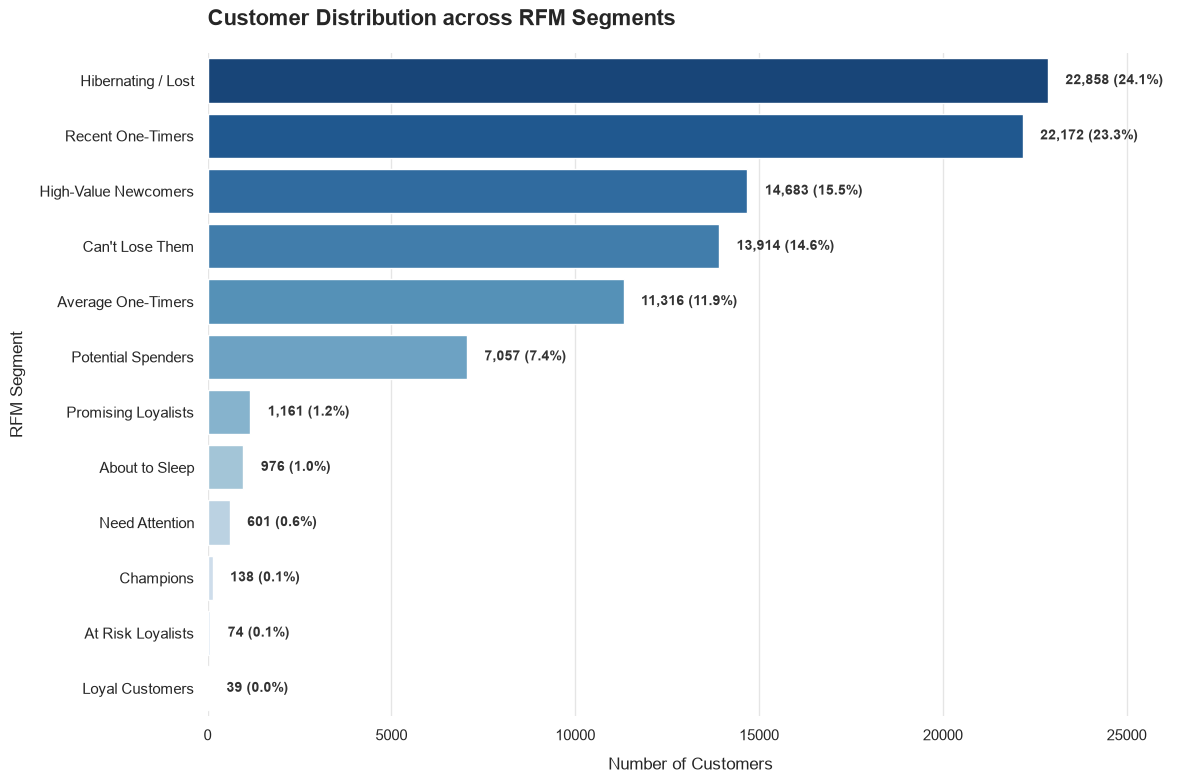

In [12]:
# 1. Przygotowanie danych (sortowanie od największego do najmniejszego segmentu)
segment_counts = df_segmented['Segment'].value_counts()
total_customers = len(df_segmented)

# 2. Ustawienie stylu i estetyki wykresu
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# 3. Stworzenie wykresu poziomego
# Używamy palety 'viridis' lub 'Blues_r' (odwrócona), co daje świetny, profesjonalny efekt wizualny
ax = sns.barplot(
    x=segment_counts.values,
    y=segment_counts.index,
    palette="Blues_r",
    hue=segment_counts.index,
    legend=False
)

# 4. Dodanie zaawansowanych etykiet tekstowych (Liczba + Procent %) na każdym słupku
for i, v in enumerate(segment_counts.values):
    percentage = (v / total_customers) * 100
    # Dynamiczny margines, żeby tekst nie nakładał się na słupek
    margin = total_customers * 0.005

    ax.text(
        v + margin,          # Pozycja X (zaraz za końcem słupka)
        i,                   # Pozycja Y (indeks słupka)
        f"{v:,} ({percentage:.1f}%)", # Tekst: formatowana liczba i procent
        va='center',         # Wyrównanie w pionie
        fontsize=10,
        fontweight='bold',
        color='#333333'
    )

# 5. Dopracowanie detali (Tytuły, opisy osi)
plt.title('Customer Distribution across RFM Segments', fontsize=16, fontweight='bold', pad=20, loc='left')
plt.xlabel('Number of Customers', fontsize=12, labelpad=10)
plt.ylabel('RFM Segment', fontsize=12, labelpad=10)

# Ustawienie limitu osi X, aby etykiety tekstowe nie ucięły się z prawej strony
plt.xlim(0, max(segment_counts.values) * 1.15)

# Usunięcie zbędnych linii ramki dla czystego designu (tzw. minimalistyczny styl)
sns.despine(left=True, bottom=True)

# Wyświetlenie wykresu
plt.tight_layout()
plt.show()

### Key Insights from Segmentation:
* **The "One-Timer" Problem:** Over 80% of the entire customer base is trapped in single-purchase segments (`Hibernating / Lost` and `Recent/Average One-Timers`). This visualizes a major business challenge: Olist is highly effective at acquiring traffic, but struggles significantly with customer retention.
* **Low-Hanging Fruits:** Segments like `High-Value Newcomers` and `Promising Loyalists` represent the highest ROI for marketing campaigns. Converting them into regular buyers should be prioritized over generic acquisition.

# Segments Profiling

In [14]:
segment_profile = df_segmented.groupby('Segment').agg(
    customer_count=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('total_orders', 'mean'),
    total_revenue=('total_spent', 'sum'),
    avg_spent_per_customer=('total_spent', 'mean')
).reset_index()

# Obliczamy procentowy udział w przychodach
total_platform_revenue = segment_profile['total_revenue'].sum()
segment_profile['revenue_share_%'] = (segment_profile['total_revenue'] / total_platform_revenue) * 100

# Sortujemy od segmentów generujących najwięcej kasy
segment_profile = segment_profile.sort_values(by='total_revenue', ascending=False)
display(segment_profile.style.format({
    'avg_recency': '{:.1f}',
    'avg_frequency': '{:.2f}',
    'total_revenue': '{:,.2f}$',
    'avg_spent_per_customer': '{:.2f}$',
    'revenue_share_%': '{:.1f}%'
}))

,Segment,customer_count,avg_recency,avg_frequency,total_revenue,avg_spent_per_customer,revenue_share_%
6,High-Value Newcomers,14683,140.9,1.00,"4,448,350.08$",302.96$,28.3%
3,Can't Lose Them,13914,444.2,1.00,"4,303,268.59$",309.28$,27.3%
9,Potential Spenders,7057,270.1,1.00,"1,972,762.07$",279.55$,12.5%
5,Hibernating / Lost,22858,445.5,1.00,"1,664,413.95$",72.82$,10.6%
11,Recent One-Timers,22172,138.8,1.00,"1,620,123.93$",73.07$,10.3%
2,Average One-Timers,11316,269.6,1.00,"815,153.05$",72.04$,5.2%
10,Promising Loyalists,1161,136.2,2.00,"337,821.14$",290.97$,2.1%
0,About to Sleep,976,431.9,2.00,"277,523.39$",284.35$,1.8%
8,Need Attention,601,267.5,2.00,"174,543.27$",290.42$,1.1%
4,Champions,138,135.3,3.49,"75,215.06$",545.04$,0.5%


### Executive Observations from Segment Profiling:

1. **High-Value Newcomers Are the Top Priority:** This segment shows an exceptional `avg_spent_per_customer`. Given their low recency (recent purchases), they represent the highest conversion potential. Marketing should target them immediately to secure a second order.
2. **The Pareto Principle in Action:** The `Champions` and `Loyal Customers` segments represent a tiny fraction of the total customer count but contribute significantly to the `revenue_share_%`. Retaining these users is highly cost-effective compared to acquiring new ones.
3. **Volume vs. Value in Hibernating Users:** While the `Hibernating / Lost` segment accounts for a massive portion of the database, their individual value is low, and they haven't interacted with the platform in a long time. High-cost retargeting campaigns should be avoided for this group.